l'idée est d'experimenter avec plusieurs fonctions d'activation, different nombre de layer et differentes dimensions de l'espace latent.



In [12]:
from src.dataset import load_mnist_dataset
from src.autoencoder import AutoEncoder
from torch import nn

import matplotlib.pyplot as plt

In [2]:
loader = load_mnist_dataset(train=True, batch_size=32)
images, labels = next(iter(loader))
print(images.shape)

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.33MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 234kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.08MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


torch.Size([32, 1, 28, 28])


In [3]:
flattened_images = images.view(images.size(0), -1).numpy()
print(flattened_images.shape)

(32, 784)


In [7]:
dim_images = flattened_images.shape[1]
facteur_de_reduction = 100
model = AutoEncoder(
    input_dim=dim_images
    , output_dim=dim_images
    , latent_dim=dim_images // facteur_de_reduction
    , encoder_layer_num=3
    , decoder_layer_num=3
    , encoder_activation=nn.ReLU
)

In [ ]:
latent = model.encode(flattened_images)
print(type(latent))
print(latent.nature)
print(latent.array.shape)


<class 'src.metrics.Latent'>
continuous
(32, 7)


In [11]:
decompressed_flattened_images = model.decode(latent)
print(decompressed_flattened_images.shape)
print(decompressed_flattened_images.min(), decompressed_flattened_images.max())

(32, 784)
0.4485453 0.5621265


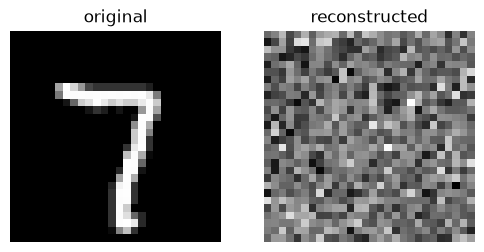

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(flattened_images[0].reshape(28, 28), cmap="gray")
axes[0].set_title("original")
axes[0].axis("off")

axes[1].imshow(decompressed_flattened_images[0].reshape(28, 28), cmap="gray")
axes[1].set_title("reconstructed")
axes[1].axis("off")

plt.show()
